<a href="https://colab.research.google.com/github/romero-sebastian/econ3916-statsml/blob/main/Lab24/Lab_24_Causal_ML_The_Frontier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# GUIDED — Run as-is
!pip install doubleml scikit-learn pandas numpy matplotlib seaborn statsmodels -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import Lasso, LassoCV, LinearRegression, LogisticRegression, RidgeCV, LogisticRegressionCV
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm

import doubleml as dml
from doubleml import DoubleMLData, DoubleMLPLR
from doubleml.datasets import fetch_401K

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {'primary': '#2C5F8A', 'secondary': '#E8613C', 'neutral': '#6B7280', 'light': '#E5EFF7'}

print("✅ All imports successful")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 603.5/603.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.3/230.3 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 1.9 MB/s eta 0:00:00
✅ All imports successful


In [2]:
# GUIDED — Run as-is
np.random.seed(42)
n = 2000
p = 50
TRUE_EFFECT = 1000

X = np.random.randn(n, p)
treatment_propensity = X[:, :5].mean(axis=1)
D = (treatment_propensity + np.random.randn(n) * 0.5 > 0).astype(float)

beta_X = np.random.randn(p) * 500
Y = TRUE_EFFECT * D + X @ beta_X + np.random.randn(n) * 1000

print(f"Simulated dataset: {n:,} obs, {p} confounders")
print(f"Treatment rate:    {D.mean():.1%}")
print(f"TRUE causal effect: ${TRUE_EFFECT:,}")
print(f"Outcome range:      ${Y.min():.0f} to ${Y.max():.0f}")

Simulated dataset: 2,000 obs, 50 confounders
Treatment rate:    50.0%
TRUE causal effect: $1,000
Outcome range:      $-11343 to $14535


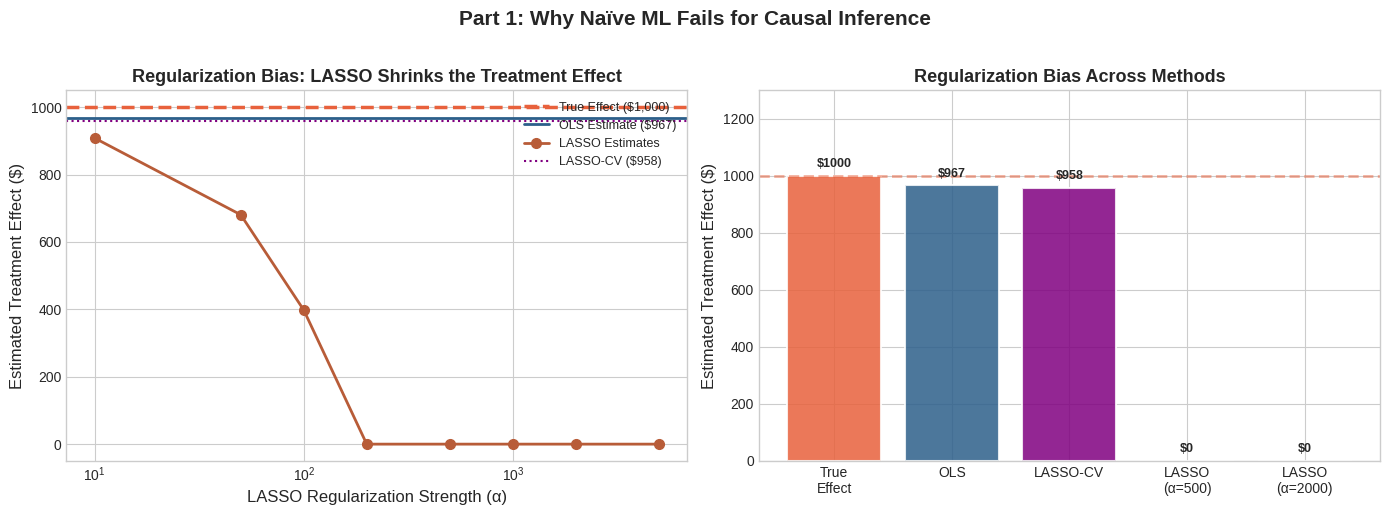


True causal effect:     $   1,000
OLS estimate:           $     967  (bias: $-33)
LASSO-CV estimate:      $     958  (bias: $-42)


In [3]:
# GUIDED — Run as-is
DX = np.column_stack([D, X])

ols = LinearRegression(fit_intercept=True)
ols.fit(DX, Y)
ols_coef = ols.coef_[0]

alphas = [10, 50, 100, 200, 500, 1000, 2000, 5000]
lasso_coefs = []
for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(DX, Y)
    lasso_coefs.append(lasso.coef_[0])

lasso_cv = LassoCV(cv=5, max_iter=10000)
lasso_cv.fit(DX, Y)
lasso_cv_coef = lasso_cv.coef_[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.axhline(TRUE_EFFECT, color=COLORS['secondary'], linewidth=2.5, linestyle='--', label=f'True Effect (${TRUE_EFFECT:,})')
ax.axhline(ols_coef, color=COLORS['primary'], linewidth=2, linestyle='-', label=f'OLS Estimate (${ols_coef:.0f})')
ax.plot(alphas, lasso_coefs, 'o-', color='#B85C38', linewidth=2, markersize=7, label='LASSO Estimates')
ax.axhline(lasso_cv_coef, color='purple', linewidth=1.5, linestyle=':', label=f'LASSO-CV (${lasso_cv_coef:.0f})')
ax.set_xlabel('LASSO Regularization Strength (α)', fontsize=12)
ax.set_ylabel('Estimated Treatment Effect ($)', fontsize=12)
ax.set_title('Regularization Bias: LASSO Shrinks the Treatment Effect', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.set_xscale('log')

ax2 = axes[1]
methods = ['True\nEffect', 'OLS', 'LASSO-CV', 'LASSO\n(α=500)', 'LASSO\n(α=2000)']
values = [TRUE_EFFECT, ols_coef, lasso_cv_coef, lasso_coefs[alphas.index(500)], lasso_coefs[alphas.index(2000)]]
colors_bar = [COLORS['secondary'], COLORS['primary'], 'purple', '#E8613C', '#B85C38']
bars = ax2.bar(methods, values, color=colors_bar, edgecolor='white', linewidth=1.5, alpha=0.85)
ax2.axhline(TRUE_EFFECT, color=COLORS['secondary'], linewidth=2, linestyle='--', alpha=0.5)
for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f'${val:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_ylabel('Estimated Treatment Effect ($)', fontsize=12)
ax2.set_title('Regularization Bias Across Methods', fontsize=13, fontweight='bold')
ax2.set_ylim(0, TRUE_EFFECT * 1.3)

plt.suptitle('Part 1: Why Naïve ML Fails for Causal Inference', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nTrue causal effect:     ${TRUE_EFFECT:>8,}")
print(f"OLS estimate:           ${ols_coef:>8,.0f}  (bias: ${ols_coef - TRUE_EFFECT:+.0f})")
print(f"LASSO-CV estimate:      ${lasso_cv_coef:>8,.0f}  (bias: ${lasso_cv_coef - TRUE_EFFECT:+.0f})")

In [4]:
# GUIDED — Run as-is
data_401k = fetch_401K(return_type='DataFrame')
print(f"Shape: {data_401k.shape}")
print(f"Columns: {data_401k.columns.tolist()}")
data_401k.head()

Shape: (9915, 14)
Columns: ['nifa', 'net_tfa', 'tw', 'age', 'inc', 'fsize', 'educ', 'db', 'marr', 'twoearn', 'e401', 'p401', 'pira', 'hown']


,nifa,net_tfa,tw,age,inc,fsize,educ,db,marr,twoearn,e401,p401,pira,hown
0,0.0,0.0,4500.0,47,6765.0,2,8,0,0,0,0,0,0,1
1,6215.0,1015.0,22390.0,36,28452.0,1,16,0,0,0,0,0,0,1
2,0.0,-2000.0,-2000.0,37,3300.0,6,12,1,0,0,0,0,0,0
3,15000.0,15000.0,155000.0,58,52590.0,2,16,0,1,1,0,0,0,1
4,0.0,0.0,58000.0,32,21804.0,1,11,0,0,0,0,0,0,1


In [5]:
# GUIDED — Run as-is
print(f"Observations:      {len(data_401k):,}")
print(f"Eligible for 401k: {data_401k['e401'].mean():.1%}")
print(f"Avg net assets:   ${data_401k['net_tfa'].mean():,.0f}")
print(f"Median income:    ${data_401k['inc'].median():,.0f}")

naive_diff = data_401k.groupby('e401')['net_tfa'].mean()
print(f"\nNaive ATE (difference-in-means):")
print(f"  Eligible:     ${naive_diff[1]:>10,.0f}")
print(f"  Not eligible: ${naive_diff[0]:>10,.0f}")
print(f"  Raw gap:      ${naive_diff[1] - naive_diff[0]:>10,.0f}")
print(f"\n This raw gap is confounded. DML will fix")

Observations:      9,915
Eligible for 401k: 37.1%
Avg net assets:   $18,052
Median income:    $31,476

Naive ATE (difference-in-means):
  Eligible:     $    30,347
  Not eligible: $    10,788
  Raw gap:      $    19,559

⚠️  This raw gap is CONFOUNDED. DML will fix this.


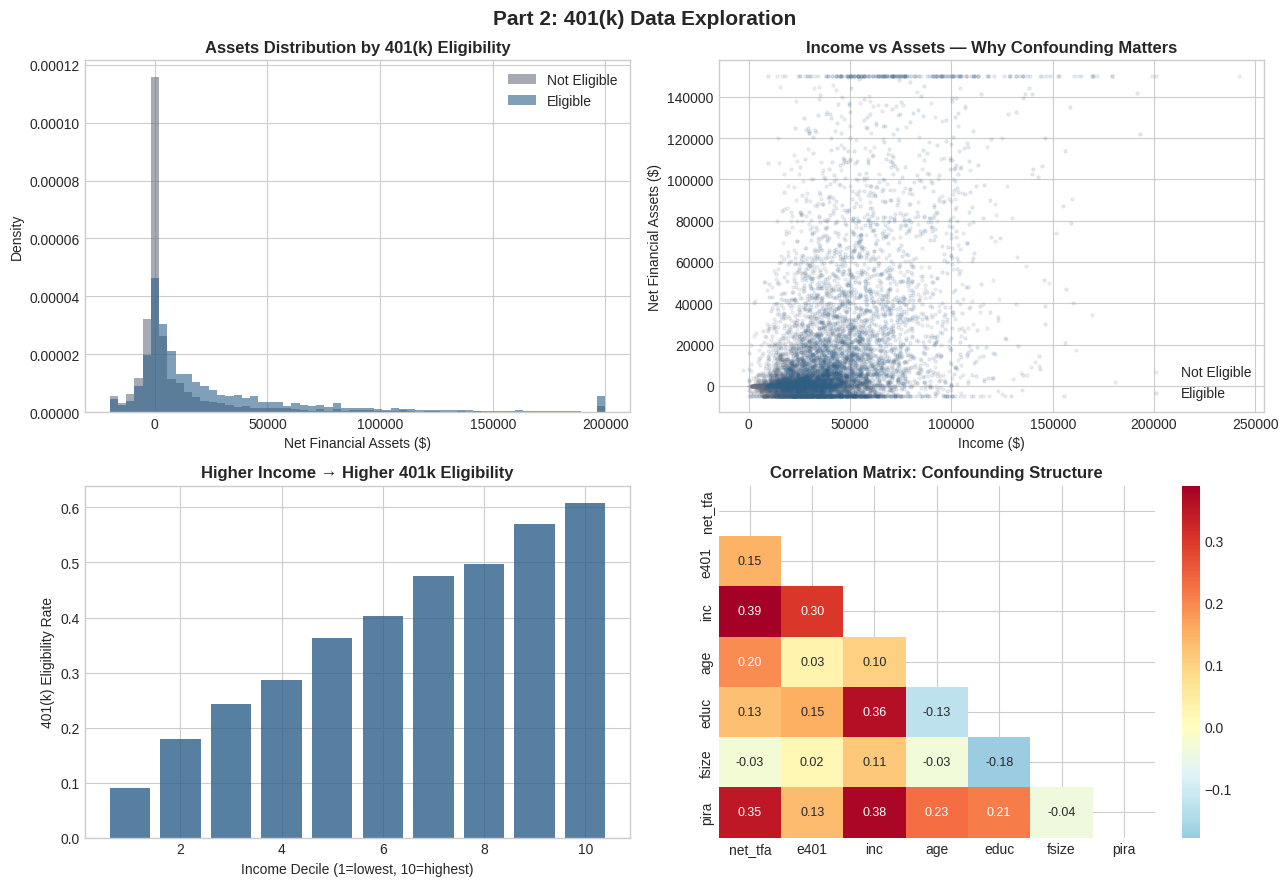

In [6]:
# GUIDED — Run as-is
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

ax = axes[0, 0]
for grp, color, label in [(0, COLORS['neutral'], 'Not Eligible'), (1, COLORS['primary'], 'Eligible')]:
    subset = data_401k[data_401k['e401'] == grp]['net_tfa']
    ax.hist(np.clip(subset, -20000, 200000), bins=60, alpha=0.6, color=color, label=label, density=True)
ax.set_xlabel('Net Financial Assets ($)')
ax.set_ylabel('Density')
ax.set_title('Assets Distribution by 401(k) Eligibility', fontweight='bold')
ax.legend()

ax = axes[0, 1]
for grp, color, label in [(0, COLORS['neutral'], 'Not Eligible'), (1, COLORS['primary'], 'Eligible')]:
    mask = data_401k['e401'] == grp
    ax.scatter(data_401k.loc[mask, 'inc'],
               np.clip(data_401k.loc[mask, 'net_tfa'], -5000, 150000),
               alpha=0.1, s=5, color=color, label=label)
ax.set_xlabel('Income ($)')
ax.set_ylabel('Net Financial Assets ($)')
ax.set_title('Income vs Assets — Why Confounding Matters', fontweight='bold')
ax.legend()

ax = axes[1, 0]
data_401k['income_decile'] = pd.qcut(data_401k['inc'], 10, labels=False)
eligibility_by_income = data_401k.groupby('income_decile')['e401'].mean()
ax.bar(range(1, 11), eligibility_by_income.values, color=COLORS['primary'], alpha=0.8)
ax.set_xlabel('Income Decile (1=lowest, 10=highest)')
ax.set_ylabel('401(k) Eligibility Rate')
ax.set_title('Higher Income → Higher 401k Eligibility', fontweight='bold')

ax = axes[1, 1]
key_vars = [v for v in ['net_tfa', 'e401', 'inc', 'age', 'educ', 'fsize', 'pira', 'married'] if v in data_401k.columns]
corr = data_401k[key_vars].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r', center=0, ax=ax, annot_kws={'size': 9})
ax.set_title('Correlation Matrix: Confounding Structure', fontweight='bold')

plt.suptitle('Part 2: 401(k) Data Exploration', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
# ✎ YOUR TASK — Fill in the blanks

y_col = 'net_tfa'    # OUTCOME
d_col = 'e401'       # TREATMENT

# Confounders — everything relevant EXCEPT p401 (downstream of treatment)
x_cols = ['age', 'inc', 'fsize', 'educ', 'pira', 'married', 'two_earner', 'male', 'db']
x_cols = [c for c in x_cols if c in data_401k.columns]
print(f"Confounders ({len(x_cols)}): {x_cols}")

dml_data = DoubleMLData(
    data=data_401k,
    y_col=y_col,
    d_cols=d_col,
    x_cols=x_cols
)

print("\n DoubleMLData created")
print(dml_data)

Confounders (6): ['age', 'inc', 'fsize', 'educ', 'pira', 'db']

✅ DoubleMLData created!
================== DoubleMLData Object ==================

------------------ Data summary      ------------------
Outcome variable: net_tfa
Treatment variable(s): ['e401']
Covariates: ['age', 'inc', 'fsize', 'educ', 'pira', 'db']
Instrument variable(s): None
No. Observations: 9915
------------------ DataFrame info    ------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9915 entries, 0 to 9914
Columns: 15 entries, nifa to income_decile
dtypes: float32(4), int64(1), int8(10)
memory usage: 329.3 KB



In [8]:
# ✎ YOUR TASK — Fill in the blanks

# Nuisance learner for outcome Y ~ X
ml_l = RandomForestRegressor(
    n_estimators=200, max_depth=5, min_samples_leaf=10, random_state=42, n_jobs=-1
)

# Nuisance learner for treatment D ~ X (binary → classifier)
ml_m = RandomForestClassifier(
    n_estimators=200, max_depth=5, min_samples_leaf=10, random_state=42, n_jobs=-1
)

# Initialize DML Partially Linear Regression
dml_plr = DoubleMLPLR(
    obj_dml_data=dml_data,
    ml_l=ml_l,
    ml_m=ml_m,
    n_folds=5,
    score='partialling out'
)

print(" Fitting DML model (1-2 minutes)...")
dml_plr.fit()
print("done")

⏳ Fitting DML model (1-2 minutes)...
✅ Done!


In [9]:
# GUIDED — Run as-is
print(dml_plr.summary)

ate     = dml_plr.coef[0]
se      = dml_plr.se[0]
ci_low  = dml_plr.confint().iloc[0, 0]
ci_high = dml_plr.confint().iloc[0, 1]
pval    = dml_plr.pval[0]

print(f"\n📊 CAUSAL EFFECT OF 401(k) ELIGIBILITY ON NET ASSETS")
print(f"  ATE Estimate:  ${ate:>10,.0f}")
print(f"  Std Error:     ${se:>10,.0f}")
print(f"  95% CI:        [${ci_low:,.0f}, ${ci_high:,.0f}]")
print(f"  P-value:       {pval:.4f}")
naive = data_401k.groupby('e401')['net_tfa'].mean().diff().iloc[-1]
print(f"\n  Naive estimate:        ${naive:,.0f}")
print(f"  DML-adjusted ATE:      ${ate:,.0f}")
print(f"  Confounding removed:   ${naive - ate:,.0f}")

             coef      std err         t         P>|t|       2.5 %  \
e401  9054.362659  1334.156071  6.786584  1.148194e-11  6439.46481   

            97.5 %  
e401  11669.260507  

📊 CAUSAL EFFECT OF 401(k) ELIGIBILITY ON NET ASSETS
  ATE Estimate:  $     9,054
  Std Error:     $     1,334
  95% CI:        [$6,439, $11,669]
  P-value:       0.0000

  Naive estimate:        $19,559
  DML-adjusted ATE:      $9,054
  Confounding removed:   $10,505


In [10]:
# ✎ YOUR TASK — Fill in the blanks

data_401k['income_quartile'] = pd.qcut(
    data_401k['inc'], q=4, labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4 (Highest)']
)

cate_results = {}

for quartile in ['Q1 (Lowest)', 'Q2', 'Q3', 'Q4 (Highest)']:
    print(f" Fitting DML for {quartile}...")
    subset = data_401k[data_401k['income_quartile'] == quartile].copy()

    dml_data_q = DoubleMLData(data=subset, y_col=y_col, d_cols=d_col, x_cols=x_cols)

    ml_l_q = RandomForestRegressor(n_estimators=100, max_depth=4, min_samples_leaf=10, random_state=42, n_jobs=-1)
    ml_m_q = RandomForestClassifier(n_estimators=100, max_depth=4, min_samples_leaf=10, random_state=42, n_jobs=-1)

    dml_plr_q = DoubleMLPLR(
        obj_dml_data=dml_data_q,
        ml_l=ml_l_q,
        ml_m=ml_m_q,
        n_folds=3,
        score='partialling out'
    )
    dml_plr_q.fit()

    cate_results[quartile] = {
        'ate':     dml_plr_q.coef[0],
        'se':      dml_plr_q.se[0],
        'ci_low':  dml_plr_q.confint().iloc[0, 0],
        'ci_high': dml_plr_q.confint().iloc[0, 1],
        'pval':    dml_plr_q.pval[0],
        'n':       len(subset),
        'mean_inc': subset['inc'].mean()
    }
    print(f"   CATE = ${dml_plr_q.coef[0]:,.0f}")

print("\n All quartile models fitted")

⏳ Fitting DML for Q1 (Lowest)...
  ✅ CATE = $4,026
⏳ Fitting DML for Q2...
  ✅ CATE = $3,491
⏳ Fitting DML for Q3...
  ✅ CATE = $7,402
⏳ Fitting DML for Q4 (Highest)...
  ✅ CATE = $17,799

✅ All quartile models fitted!


Quartile                N     Mean Inc       CATE                     95% CI
---------------------------------------------------------------------------
Q1 (Lowest)         2,481 $     12,905 $    4,026  [$1,862, $6,190]
Q2                  2,477 $     25,388 $    3,491  [$1,085, $5,898]
Q3                  2,478 $     39,277 $    7,402  [$3,855, $10,949]
Q4 (Highest)        2,479 $     71,243 $   17,799  [$10,007, $25,590]


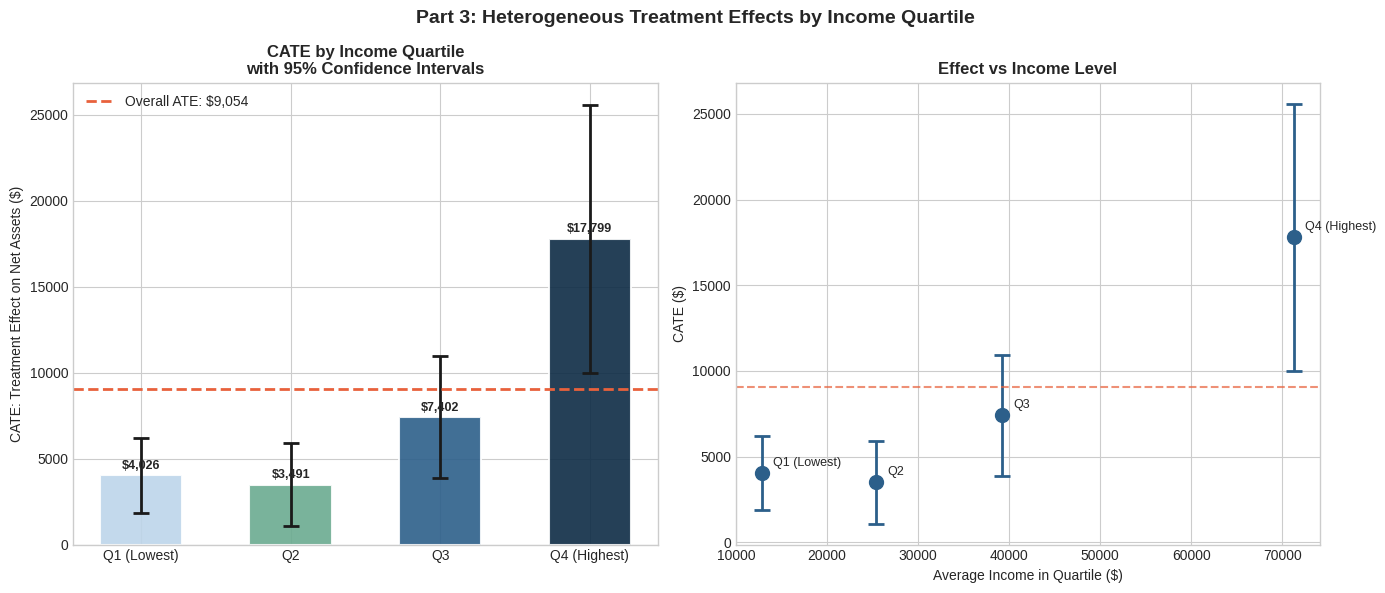

In [11]:
# GUIDED — Run as-is
cate_df = pd.DataFrame(cate_results).T.reset_index()
cate_df.columns = ['Quartile'] + [c for c in cate_df.columns[1:]]
for col in ['ate', 'se', 'ci_low', 'ci_high', 'pval', 'n', 'mean_inc']:
    cate_df[col] = pd.to_numeric(cate_df[col])

print(f"{'Quartile':<18} {'N':>6} {'Mean Inc':>12} {'CATE':>10} {'95% CI':>26}")
print("-" * 75)
for _, row in cate_df.iterrows():
    print(f"{row['Quartile']:<18} {row['n']:>6,.0f} ${row['mean_inc']:>11,.0f} "
          f"${row['ate']:>9,.0f}  [${row['ci_low']:,.0f}, ${row['ci_high']:,.0f}]")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
colors_cate = ['#BDD5EA', '#6BAB90', '#2C5F8A', '#0D2B45']
x_pos = range(len(cate_df))
bars = ax.bar(x_pos, cate_df['ate'], color=colors_cate[:len(cate_df)],
              edgecolor='white', linewidth=1.5, alpha=0.9, width=0.55)
ax.errorbar(x_pos, cate_df['ate'],
            yerr=[cate_df['ate'] - cate_df['ci_low'], cate_df['ci_high'] - cate_df['ate']],
            fmt='none', color='#1a1a1a', capsize=6, linewidth=2, capthick=2)
ax.axhline(ate, color=COLORS['secondary'], linewidth=2, linestyle='--', label=f'Overall ATE: ${ate:,.0f}')
ax.set_xticks(x_pos)
ax.set_xticklabels(cate_df['Quartile'], fontsize=10)
ax.set_ylabel('CATE: Treatment Effect on Net Assets ($)')
ax.set_title('CATE by Income Quartile\nwith 95% Confidence Intervals', fontweight='bold')
ax.legend()
for bar, val in zip(bars, cate_df['ate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'${val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2 = axes[1]
ax2.errorbar(cate_df['mean_inc'], cate_df['ate'],
             yerr=[cate_df['ate'] - cate_df['ci_low'], cate_df['ci_high'] - cate_df['ate']],
             fmt='o', color=COLORS['primary'], capsize=6, markersize=10, linewidth=2, capthick=2)
for _, row in cate_df.iterrows():
    ax2.annotate(row['Quartile'], (row['mean_inc'], row['ate']),
                 textcoords='offset points', xytext=(8, 5), fontsize=9)
ax2.axhline(ate, color=COLORS['secondary'], linewidth=1.5, linestyle='--', alpha=0.7)
ax2.set_xlabel('Average Income in Quartile ($)')
ax2.set_ylabel('CATE ($)')
ax2.set_title('Effect vs Income Level', fontweight='bold')

plt.suptitle('Part 3: Heterogeneous Treatment Effects by Income Quartile', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# GUIDED — Run as-is
learner_configs = {
    'Random Forest (baseline)': {
        'ml_l': RandomForestRegressor(n_estimators=200, max_depth=5, min_samples_leaf=10, random_state=42, n_jobs=-1),
        'ml_m': RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_leaf=10, random_state=42, n_jobs=-1)
    },
    'Gradient Boosting': {
        'ml_l': GradientBoostingRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42),
        'ml_m': GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
    },
    'Ridge / Logistic': {
        'ml_l': RidgeCV(alphas=[0.1, 1.0, 10.0, 100.0]),
        'ml_m': LogisticRegressionCV(cv=5, max_iter=500)
    },
}

sensitivity_results = {}
for name, config in learner_configs.items():
    print(f"Fitting: {name}...")
    model = DoubleMLPLR(
        obj_dml_data=dml_data,
        ml_l=config['ml_l'],
        ml_m=config['ml_m'],
        n_folds=5,
        score='partialling out'
    )
    model.fit()
    sensitivity_results[name] = {
        'ate': model.coef[0], 'se': model.se[0],
        'ci_low': model.confint().iloc[0, 0],
        'ci_high': model.confint().iloc[0, 1]
    }
    print(f"  ATE = ${model.coef[0]:,.0f}")

print("✅ Sensitivity analysis complete!")

Fitting: Random Forest (baseline)...
  ATE = $9,090
Fitting: Gradient Boosting...
  ATE = $9,580
Fitting: Ridge / Logistic...
  ATE = $5,815
✅ Sensitivity analysis complete!


Fitting with 2 folds...
  ATE = $9,264
Fitting with 3 folds...
  ATE = $8,984
Fitting with 5 folds...
  ATE = $9,117
Fitting with 10 folds...
  ATE = $8,891


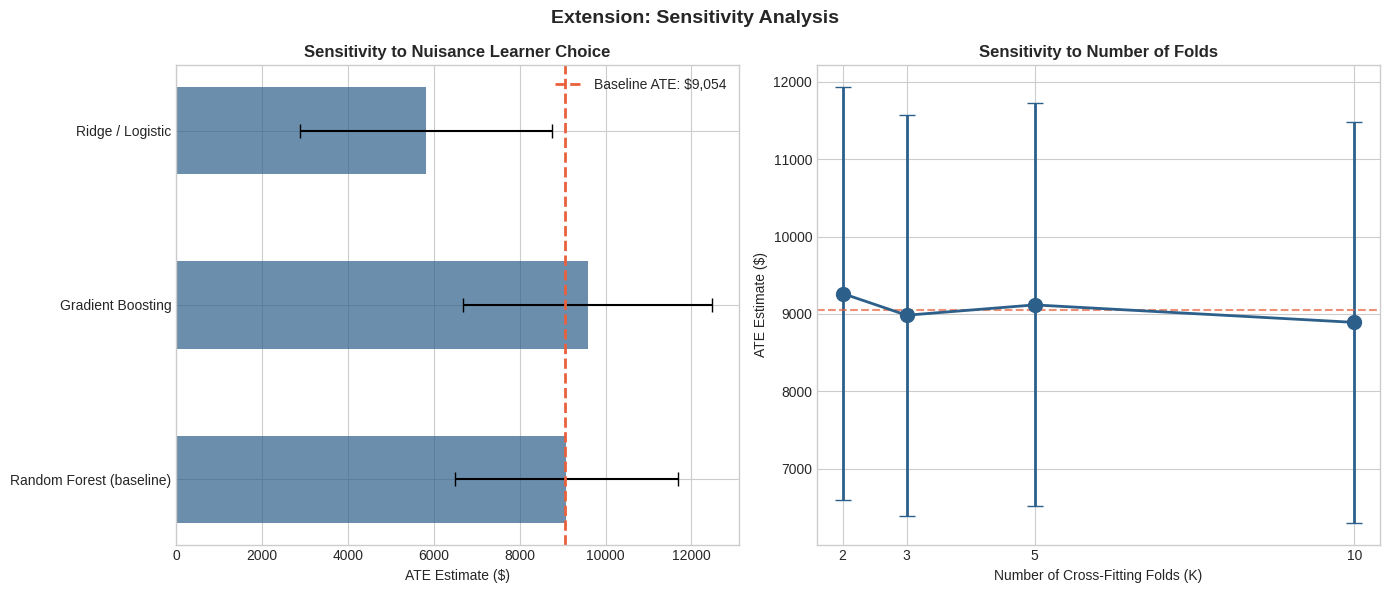

In [13]:
# GUIDED — Run as-is
fold_results = {}
for n_folds in [2, 3, 5, 10]:
    print(f"Fitting with {n_folds} folds...")
    model = DoubleMLPLR(
        obj_dml_data=dml_data,
        ml_l=RandomForestRegressor(n_estimators=100, max_depth=5, min_samples_leaf=10, random_state=42, n_jobs=-1),
        ml_m=RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_leaf=10, random_state=42, n_jobs=-1),
        n_folds=n_folds,
        score='partialling out'
    )
    model.fit()
    fold_results[n_folds] = {
        'ate': model.coef[0], 'se': model.se[0],
        'ci_low': model.confint().iloc[0, 0],
        'ci_high': model.confint().iloc[0, 1]
    }
    print(f"  ATE = ${model.coef[0]:,.0f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
sens_df = pd.DataFrame(sensitivity_results).T
y_pos = range(len(sens_df))
ax.barh(y_pos, sens_df['ate'],
        xerr=[sens_df['ate'] - sens_df['ci_low'], sens_df['ci_high'] - sens_df['ate']],
        color=COLORS['primary'], alpha=0.7, capsize=5, height=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(sens_df.index, fontsize=10)
ax.axvline(ate, color=COLORS['secondary'], linewidth=2, linestyle='--', label=f'Baseline ATE: ${ate:,.0f}')
ax.set_xlabel('ATE Estimate ($)')
ax.set_title('Sensitivity to Nuisance Learner Choice', fontweight='bold')
ax.legend()

ax2 = axes[1]
fold_df = pd.DataFrame(fold_results).T
ax2.errorbar(fold_df.index, fold_df['ate'],
             yerr=[fold_df['ate'] - fold_df['ci_low'], fold_df['ci_high'] - fold_df['ate']],
             fmt='o-', color=COLORS['primary'], capsize=6, linewidth=2, markersize=10)
ax2.axhline(ate, color=COLORS['secondary'], linewidth=1.5, linestyle='--', alpha=0.7)
ax2.set_xlabel('Number of Cross-Fitting Folds (K)')
ax2.set_ylabel('ATE Estimate ($)')
ax2.set_title('Sensitivity to Number of Folds', fontweight='bold')
ax2.set_xticks([2, 3, 5, 10])

plt.suptitle('Extension: Sensitivity Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

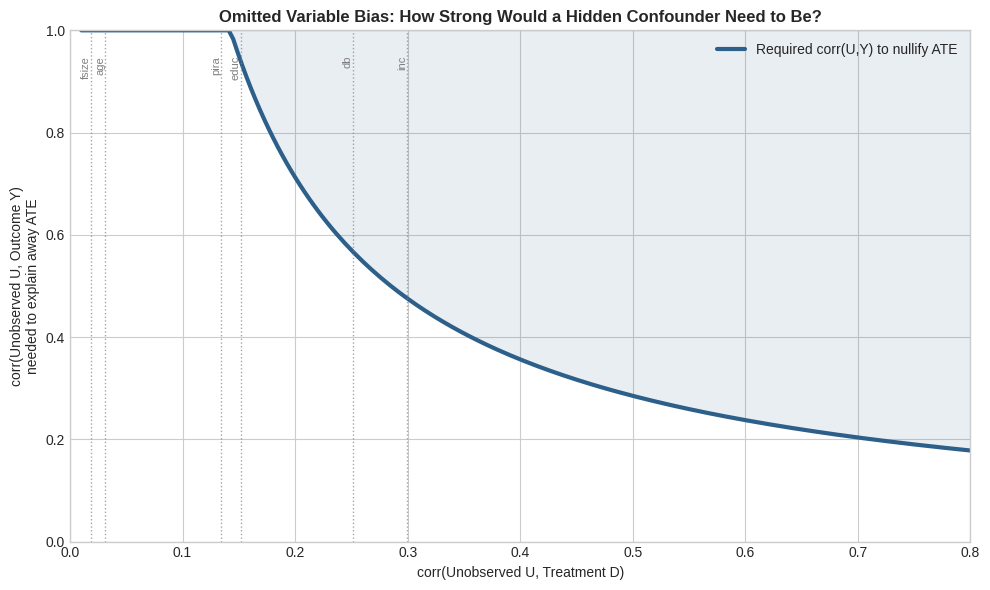

An omitted confounder needs corr(U,D) × corr(U,Y) > 0.143 to nullify the ATE.


In [14]:
# GUIDED — Run as-is
y_std = data_401k['net_tfa'].std()
normalized_ate = ate / y_std

corr_UD = np.linspace(0.01, 0.8, 200)
required_corr_UY = np.clip(normalized_ate / corr_UD, 0, 1)

observed_corrs = {col: abs(data_401k[[col, 'e401']].corr().iloc[0, 1]) for col in x_cols}

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(corr_UD, required_corr_UY, color=COLORS['primary'], linewidth=3,
        label='Required corr(U,Y) to nullify ATE')
ax.fill_between(corr_UD, required_corr_UY, 1, alpha=0.1, color=COLORS['primary'])
for col, corr_val in list(observed_corrs.items())[:6]:
    ax.axvline(corr_val, color='gray', linewidth=1, linestyle=':', alpha=0.7)
    ax.text(corr_val, 0.95, col, rotation=90, va='top', ha='right', fontsize=8, color='gray')
ax.set_xlabel('corr(Unobserved U, Treatment D)')
ax.set_ylabel('corr(Unobserved U, Outcome Y)\nneeded to explain away ATE')
ax.set_title('Omitted Variable Bias: How Strong Would a Hidden Confounder Need to Be?', fontweight='bold')
ax.legend()
ax.set_xlim(0, 0.8)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

print(f"An omitted confounder needs corr(U,D) × corr(U,Y) > {normalized_ate:.3f} to nullify the ATE.")

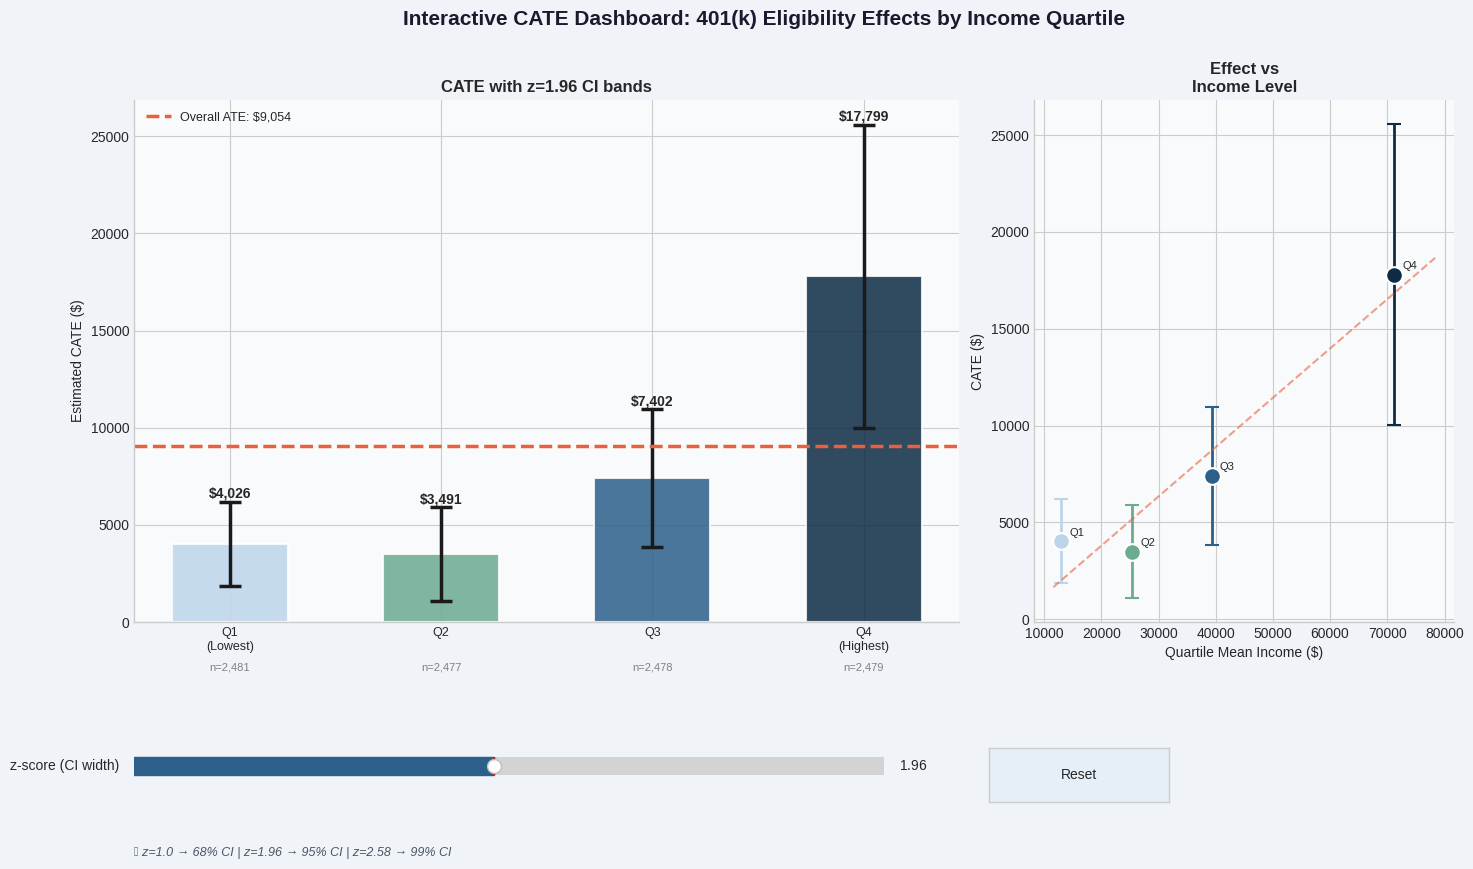

In [15]:
# 🤖 AI EXPANSION — Co-Pilot required
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button
import numpy as np

quartile_labels = list(cate_results.keys())
ates_q    = [cate_results[q]['ate']     for q in quartile_labels]
ses_q     = [cate_results[q]['se']      for q in quartile_labels]
incomes_q = [cate_results[q]['mean_inc'] for q in quartile_labels]
ns_q      = [cate_results[q]['n']       for q in quartile_labels]
q_colors  = ['#BDD5EA', '#6BAB90', '#2C5F8A', '#0D2B45']

fig = plt.figure(figsize=(15, 9), facecolor='#F0F4F8')
fig.suptitle('Interactive CATE Dashboard: 401(k) Eligibility Effects by Income Quartile',
             fontsize=15, fontweight='bold', color='#1a1a2e')

ax_main   = fig.add_axes([0.08, 0.30, 0.55, 0.58])
ax_income = fig.add_axes([0.68, 0.30, 0.28, 0.58])
ax_slider = fig.add_axes([0.08, 0.12, 0.50, 0.04])
ax_btn    = fig.add_axes([0.65, 0.10, 0.12, 0.06])

def draw(z=1.96):
    ax_main.clear()
    ax_income.clear()
    x = np.arange(len(quartile_labels))

    for i, (a, se, c) in enumerate(zip(ates_q, ses_q, q_colors)):
        ci = z * se
        ax_main.bar(i, a, color=c, alpha=0.85, width=0.55, edgecolor='white', linewidth=1.5)
        ax_main.errorbar(i, a, yerr=ci, fmt='none', color='#1a1a1a', capsize=8, linewidth=2.5, capthick=2.5)
        ax_main.text(i, a + ci + 200, f'${a:,.0f}', ha='center', fontsize=10, fontweight='bold')
        ax_main.text(i, -2500, f'n={ns_q[i]:,}', ha='center', fontsize=8, color='gray')

    ax_main.axhline(ate, color=COLORS['secondary'], linewidth=2.5, linestyle='--', label=f'Overall ATE: ${ate:,.0f}')
    ax_main.set_xticks(x)
    ax_main.set_xticklabels([q.replace(' ', '\n') for q in quartile_labels], fontsize=9)
    ax_main.set_ylabel('Estimated CATE ($)')
    ax_main.set_title(f'CATE with z={z:.2f} CI bands', fontweight='bold')
    ax_main.legend(fontsize=9)
    ax_main.set_facecolor('#F8FAFC')
    ax_main.spines['top'].set_visible(False)
    ax_main.spines['right'].set_visible(False)

    for i, (inc, a, se, c, q) in enumerate(zip(incomes_q, ates_q, ses_q, q_colors, quartile_labels)):
        ax_income.errorbar(inc, a, yerr=z*se, fmt='o', color=c, markersize=12, linewidth=2,
                           capsize=5, capthick=2, markeredgecolor='white', markeredgewidth=1.5)
        ax_income.annotate(q.split(' ')[0], (inc, a), textcoords='offset points', xytext=(6, 4), fontsize=8)

    z_line = np.polyfit(incomes_q, ates_q, 1)
    x_line = np.linspace(min(incomes_q)*0.9, max(incomes_q)*1.1, 100)
    ax_income.plot(x_line, np.poly1d(z_line)(x_line), '--', color=COLORS['secondary'], alpha=0.6)
    ax_income.set_xlabel('Quartile Mean Income ($)')
    ax_income.set_ylabel('CATE ($)')
    ax_income.set_title('Effect vs\nIncome Level', fontweight='bold')
    ax_income.set_facecolor('#F8FAFC')
    ax_income.spines['top'].set_visible(False)
    ax_income.spines['right'].set_visible(False)
    fig.canvas.draw_idle()

draw()

slider = Slider(ax_slider, 'z-score (CI width)', 1.0, 3.0, valinit=1.96, color=COLORS['primary'])
slider.on_changed(lambda val: draw(slider.val))

btn = Button(ax_btn, 'Reset', color='#E5EFF7')
btn.on_clicked(lambda e: slider.reset())

fig.text(0.08, 0.04, ' z=1.0 → 68% CI | z=1.96 → 95% CI | z=2.58 → 99% CI',
         fontsize=9, color='#4B5563', style='italic')
plt.show()

In [16]:
# GUIDED — Run as-is
print("  CHAPTER 24 LAB — DML COMPLETE RESULTS SUMMARY")

print(f"\n PART 1: Regularization Bias")
print(f"   True effect:     ${TRUE_EFFECT:,}")
print(f"   OLS:             ${ols_coef:,.0f}")
print(f"   LASSO-CV:        ${lasso_cv_coef:,.0f}  ← biased toward zero")

naive = data_401k.groupby('e401')['net_tfa'].mean().diff().iloc[-1]
print(f"\n PART 2: DML ATE")
print(f"   Naive estimate:  ${naive:,.0f}  ← confounded")
print(f"   DML ATE:         ${ate:,.0f}  ← causal")
print(f"   95% CI:          [${ci_low:,.0f}, ${ci_high:,.0f}]")
print(f"   p-value:         {pval:.4f}")

print(f"\n PART 3: CATE by Income Quartile")
for q, r in cate_results.items():
    print(f"   {q:<20}: ${r['ate']:>8,.0f}  (n={r['n']:,})")

  CHAPTER 24 LAB — DML COMPLETE RESULTS SUMMARY

 PART 1: Regularization Bias
   True effect:     $1,000
   OLS:             $967
   LASSO-CV:        $958  ← biased toward zero

 PART 2: DML ATE
   Naive estimate:  $19,559  ← confounded
   DML ATE:         $9,054  ← causal
   95% CI:          [$6,439, $11,669]
   p-value:         0.0000

 PART 3: CATE by Income Quartile
   Q1 (Lowest)         : $   4,026  (n=2,481)
   Q2                  : $   3,491  (n=2,477)
   Q3                  : $   7,402  (n=2,478)
   Q4 (Highest)        : $  17,799  (n=2,479)
